## DECISION TREE

Problem Statement

- To Classify the flower as Setosa / Versicolor / Virginica based on the given features sepal length & width and petal length & width using Decision Tree Classifier.

IMPORTING NECESSARY LIBRARIES

In [26]:
# Basic libraries
import numpy as np
import pandas as pd
# Loading dataset from SKlearn library
from sklearn.datasets import load_iris
# Importing decision tree and train test split
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
# Evaluation method
from sklearn.metrics import accuracy_score
# Visualization
import matplotlib.pyplot as plt


LOADING THE DATASET

In [27]:
dataset = load_iris()    # Loading iris dataset

In [28]:
dataset

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

It has the whole details about the iris dataset including features, target, Description and etc.,


PREPARING THE DATASET

In [29]:
df = pd.DataFrame(dataset.data, columns= dataset.feature_names)   # Convert into pandas Dataframe
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [30]:
df['target'] = dataset.target   # Create a new target column
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


SUMMARIZING THE DATASET

In [31]:
df.head()    # Printing top 5 records

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [32]:
df.shape   # Shape of the dataset

(150, 5)

In [33]:
df.info()   # Information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


- There are 150 records which has 150 rows and 5 columns.
- There are no null values.
- 5 numerical columns(float- 4 and int- 1) and no categorical column
- The dataset consumes 6 KB of memory.

In [34]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


- It displays overall count, mean, Standard deviation, minimum, maximum,25%, 50%,75% distribution of data.
- The statistical summary of data shows, the data is evenly distributed in all four columns.
- Sepal width and petal length mean value is closer with each other.

In [35]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [36]:
df.head(50)  # Printing top 50 records

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [37]:
df.iloc[50,:]   # Printing 50th row

,50
sepal length (cm),7.0
sepal width (cm),3.2
petal length (cm),4.7
petal width (cm),1.4
target,1.0


In [38]:
df.iloc[50:101,]  # Printing the records from 50 to 100

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1
55,5.7,2.8,4.5,1.3,1
56,6.3,3.3,4.7,1.6,1
57,4.9,2.4,3.3,1.0,1
58,6.6,2.9,4.6,1.3,1
59,5.2,2.7,3.9,1.4,1


In [39]:
df.iloc[100:,]    # Printing from 100 to the remaining records

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2
105,7.6,3.0,6.6,2.1,2
106,4.9,2.5,4.5,1.7,2
107,7.3,2.9,6.3,1.8,2
108,6.7,2.5,5.8,1.8,2
109,7.2,3.6,6.1,2.5,2


In [40]:
df['target'].values     # Printing target values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

PREPROCESSING THE DATASET

In [41]:
df.isnull().sum()   # Checking the sum of null values

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


SPLITTING THE DATASET INTO INPUT AND OUTPUT

In [42]:
x = df.iloc[:,:-1].values       # Splitting features (x)
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [43]:
y = df['target'].values   # Splitting target values(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

SPLITTNG THE DATASET INTO TRAINING AND TESTING

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)  # Splitting dataset for training(80%) and testing(20%)

In [45]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape    # Checking the shape after splitting

((120, 4), (30, 4), (120,), (30,))

FINDING THE BEST MAXIMUM DEPTH VALUES

In [46]:
model = DecisionTreeClassifier(max_depth=3)  # Loading the model with max_depth 3
model.fit(x_train,y_train)                   # Training the model
y_pred = model.predict(x_test)               # Predict using test data
accuracy_score(y_pred, y_test)               # Checking accuracy score

0.9333333333333333

The model gives 93% accuracy

Checking the accuracy score for max depth from 1 to 10.

In [47]:
for i in range(1,11):
  model = DecisionTreeClassifier(max_depth=i)
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  print(i)
  print(accuracy_score(y_pred, y_test))

1
0.6666666666666666
2
0.9
3
0.9333333333333333
4
0.9333333333333333
5
0.9
6
0.9333333333333333
7
0.9333333333333333
8
0.9
9
0.9
10
0.9333333333333333


In [48]:
lst = []

for i in range(1,11):
  model = DecisionTreeClassifier(max_depth=i)
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  print(i)
  print(accuracy_score(y_pred, y_test))
  lst.append(accuracy_score(y_pred,y_test))

1
0.6666666666666666
2
0.9
3
0.9333333333333333
4
0.9333333333333333
5
0.9
6
0.9
7
0.9333333333333333
8
0.9
9
0.9333333333333333
10
0.9


In [49]:
lst

[0.6666666666666666,
 0.9,
 0.9333333333333333,
 0.9333333333333333,
 0.9,
 0.9,
 0.9333333333333333,
 0.9,
 0.9333333333333333,
 0.9]

Plot the accuracy for various max depth

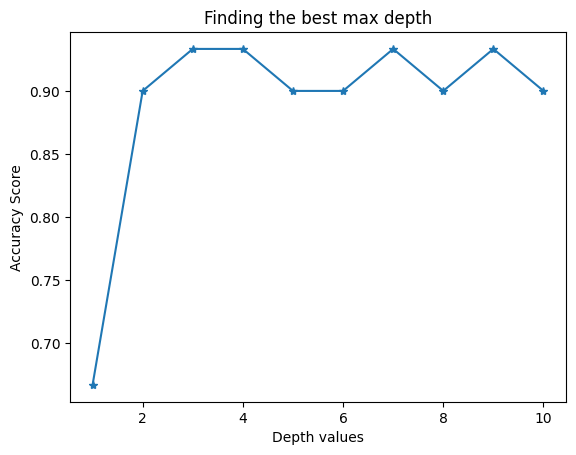

In [50]:
plt.plot(range(1,11),lst, marker  = '*')
plt.xlabel("Depth values")
plt.ylabel("Accuracy Score")
plt.title("Finding the best max depth")
plt.show()

Based on this diagram, we are fixing 3 as the maximum depth.

Next, we will try to optimize the parameters to check the accuracy score and how the model reacts will varying the parameters.

LOADING THE MODEL

In [51]:
model_ = DecisionTreeClassifier(max_depth=3, criterion= 'entropy')

TRAINING THE MODEL

In [52]:
model_.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

TESTING THE MODEL

In [53]:
y_pred_ = model_.predict(x_test)

In [54]:
y_pred_

array([0, 0, 0, 2, 1, 0, 0, 2, 1, 1, 2, 0, 2, 0, 2, 0, 1, 2, 0, 2, 0, 1,
       0, 1, 1, 1, 1, 2, 2, 0])

CALCULATING THE ACCURACY OF THE TRAINED MODEL

In [55]:
accuracy_score(y_pred_,y_test)

0.9

Now the accuracy remain 90%

PREDICTING THE OUTPUT OF SINGLE TEST DATA USING THE TRAINED MODEL

In [56]:
model_.predict([x_test[0]])

array([0])

Predicted output as setosa

In [57]:
y_test[0]

np.int64(0)

Actual output as Setosa.

VISUALIZING THE TREE

In [58]:
from sklearn.tree import export_text

In [59]:
test_rep = export_text(model_, feature_names=dataset.feature_names)

In [60]:
dataset.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
print(test_rep)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 5.05
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  5.05
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- class: 2



- First, the model checks petal length.
    - If petal length ≤ 2.45 cm → Class 0
    - This branch identifies Iris Setosa very clearly.
- If petal length > 2.45 cm, the model checks petal width.
- If petal width > 1.75 cm → Class 2
    - This generally identifies Iris Virginica.
- If petal width ≤ 1.75 cm, the model checks petal length again:
    - Petal length ≤ 5.05 cm → Class 1 → generally Iris Versicolor
    - Petal length > 5.05 cm → Class 2 → generally Iris Virginica

**The Decision Tree mainly uses petal length and petal width to classify Iris flowers. Petal length ≤ 2.45 cm is enough to identify Setosa.
For the remaining flowers, petal width and petal length help distinguish Versicolor from Virginica.**

***Observation***

- Here, Petal length is the Root Node, meaning it is the most useful feature for the first split.
- Petal width is the second important feature. It is a child node.
- Here, the tree doesn't use sepal length or sepal width for these decisions.

Class labels in the sklearn Iris dataset are:

0 → Setosa
1 → Versicolor
2 → Virginica